# Leukemia Detection - EfficientNet-B3 Transfer Learning

## Import Libraries

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

## Dataset Loading

In [6]:
train_dir = '/kaggle/input/datasets/avk256/cnmc-leukemia/fold_0/fold_0'
val_dir   = '/kaggle/input/datasets/avk256/cnmc-leukemia/fold_1/fold_1'
test_dir  = '/kaggle/input/datasets/avk256/cnmc-leukemia/fold_2/fold_2'

## Data Preprocessing

In [7]:
datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = datagen.flow_from_directory(
    train_dir, target_size=(224,224), batch_size=32,
    class_mode='binary', shuffle=True
)

val_gen = datagen.flow_from_directory(
    val_dir, target_size=(224,224), batch_size=32,
    class_mode='binary', shuffle=False
)

test_gen = datagen.flow_from_directory(
    test_dir, target_size=(224,224), batch_size=32,
    class_mode='binary', shuffle=False
)

Found 3527 images belonging to 2 classes.
Found 3581 images belonging to 2 classes.
Found 3553 images belonging to 2 classes.


## Model Building

In [8]:
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

I0000 00:00:1771546895.283225      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771546895.289027      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,264 (42.64 MB)

 Trainable params: 393,729 (1.50 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

## Model Compilation

In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Model Training

In [10]:
history = model.fit(train_gen, epochs=10, validation_data=val_gen)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1771546913.859965     146 service.cc:152] XLA service 0x7c97ac21da30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771546913.860032     146 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771546913.860040     146 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771546917.339691     146 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-20 00:22:06.320402: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 00:22:06.466876: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 00:22:06.832829: E external/local_xl

 22/111 ━━━━━━━━━━━━━━━━━━━━ 21s 243ms/step - accuracy: 0.5672 - loss: 0.7290

2026-02-20 00:22:33.776876: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 00:22:33.914963: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 00:22:34.227385: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 00:22:34.373132: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 00:22:35.074652: E external/local_xla/xla/stream_

111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.6357 - loss: 0.6772

2026-02-20 00:23:55.047420: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 00:23:55.194294: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 00:23:55.552933: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 00:23:55.699516: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 00:23:56.424038: E external/local_xla/xla/stream_

111/111 ━━━━━━━━━━━━━━━━━━━━ 142s 933ms/step - accuracy: 0.6359 - loss: 0.6770 - val_accuracy: 0.6752 - val_loss: 0.6316
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 15s 134ms/step - accuracy: 0.6614 - loss: 0.6569 - val_accuracy: 0.6752 - val_loss: 0.6357
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 15s 132ms/step - accuracy: 0.6847 - loss: 0.6362 - val_accuracy: 0.6752 - val_loss: 0.6336
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 15s 138ms/step - accuracy: 0.6905 - loss: 0.6287 - val_accuracy: 0.6752 - val_loss: 0.6365
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 16s 142ms/step - accuracy: 0.6694 - loss: 0.6402 - val_accuracy: 0.6752 - val_loss: 0.6310
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 15s 136ms/step - accuracy: 0.6797 - loss: 0.6358 - val_accuracy: 0.6752 - val_loss: 0.6302
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 15s 136ms/step - accuracy: 0.6883 - loss: 0.6218 - val_accuracy: 0.6752 - val_loss: 0.6313
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 15s 138ms/step - accuracy: 0.6828 - loss: 0.6367 - va

## Evaluation

In [11]:
loss, acc = model.evaluate(test_gen)
print(f'Test Accuracy: {acc*100:.2f}%')
print(f'Test Loss: {loss:.4f}')

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.9453 - loss: 0.4201

2026-02-20 00:26:53.631049: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 00:26:53.765224: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 00:26:54.052988: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 00:26:54.192004: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 00:26:54.859631: E external/local_xla/xla/stream_

112/112 ━━━━━━━━━━━━━━━━━━━━ 40s 358ms/step - accuracy: 0.9408 - loss: 0.4236
Test Accuracy: 69.15%
Test Loss: 0.6178


## Results Visualization

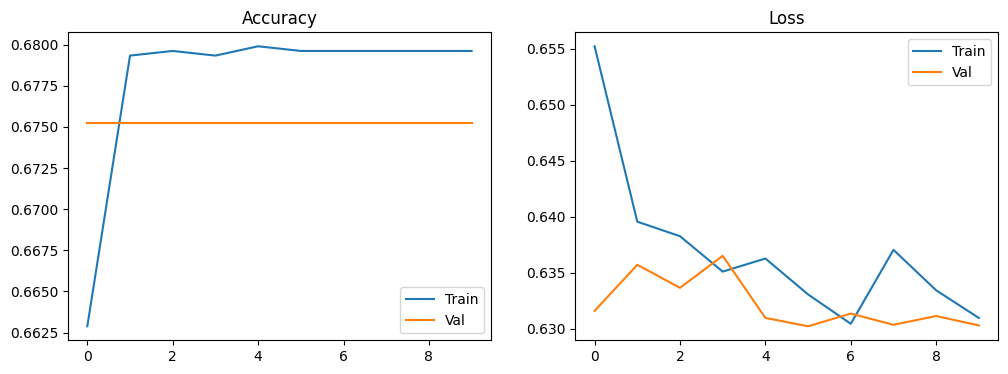

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss')
ax2.legend()

plt.show()

112/112 ━━━━━━━━━━━━━━━━━━━━ 25s 144ms/step


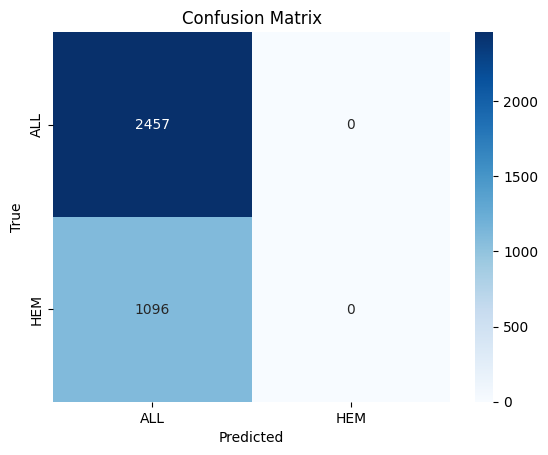

In [13]:
# Confusion Matrix
test_gen.reset()
y_pred = (model.predict(test_gen) > 0.5).astype(int).flatten()
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ALL','HEM'], yticklabels=['ALL','HEM'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [14]:
# Classification Report
print(classification_report(y_true, y_pred, target_names=['ALL','HEM']))

              precision    recall  f1-score   support

         ALL       0.69      1.00      0.82      2457
         HEM       0.00      0.00      0.00      1096

    accuracy                           0.69      3553
   macro avg       0.35      0.50      0.41      3553
weighted avg       0.48      0.69      0.57      3553



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
